# 📦 Dataset Caching

- Copying the mitosis dataset to Kaggle's working directory to speed up data access.
- Checks if a cached copy exists to avoid redundant copying.
- Sets `dataset_dir` for consistent usage in later cells.


In [ ]:
import os, shutil

# Define source and destination
src = "/kaggle/input/mitosis-detection-dataset"
dst = "/kaggle/working/mitosis-dataset-cache"

# Copy only if not already cached
if not os.path.exists(dst):
    print("📦 Caching dataset for faster access...")
    shutil.copytree(src, dst)
else:
    print("✅ Using cached dataset!")

# Update your dataset path everywhere in code
dataset_dir = dst
print("📁 Dataset directory set to:", dataset_dir)


📦 Caching dataset for faster access...


FileNotFoundError: [Errno 2] No such file or directory: '/kaggle/input/mitosis-detection-dataset'

# 🔹 GPU Check

- Verifies that GPU is available for faster training.
- Displays the number of GPUs and GPU name.


In [ ]:
import torch
print("GPU available?", torch.cuda.is_available())
print("Number of GPUs:", torch.cuda.device_count())
print("GPU Name:", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "None")


GPU available? False
Number of GPUs: 0
GPU Name: None


# 📚 Libraries and Modules

- PyTorch & torchvision for deep learning and Faster R-CNN.
- PIL and NumPy for image handling.
- `autocast` and `GradScaler` for mixed precision training.
- `tqdm` for progress bars.


In [ ]:
import os
import random
import torch
from torch.utils.data import DataLoader, Dataset
from PIL import Image
import numpy as np
from torchvision import transforms
import torchvision
from torchvision.models.detection.faster_rcnn import FastRCNNPredictor
from torch.cuda.amp import autocast, GradScaler
from tqdm import tqdm

# 🔍 Dataset Exploration

- Iterates through directories to inspect dataset structure.
- Displays the first few files in each folder to verify images and labels.


In [ ]:
import os

for dirname, _, filenames in os.walk(dataset_dir):  # no quotes here
    print(f"\nDirectory: {dirname}")
    for i, filename in enumerate(filenames):
        if i < 10:   # show only first 10 files
            print("   ", os.path.join(dirname, filename))
    if len(filenames) > 10:
        print(f"   ... and {len(filenames)-10} more files")




Directory: /kaggle/working/mitosis-dataset-cache
    /kaggle/working/mitosis-dataset-cache/README.roboflow.txt
    /kaggle/working/mitosis-dataset-cache/data.yaml
    /kaggle/working/mitosis-dataset-cache/README.dataset.txt

Directory: /kaggle/working/mitosis-dataset-cache/test

Directory: /kaggle/working/mitosis-dataset-cache/test/images
    /kaggle/working/mitosis-dataset-cache/test/images/A07_02Ac_jpg.rf.ca5955653fddd651ec2ae785b4b806d0.jpg
    /kaggle/working/mitosis-dataset-cache/test/images/A05_01Cb_jpg.rf.0e5de3c07299555295097d07800323ca.jpg
    /kaggle/working/mitosis-dataset-cache/test/images/A03_01Aa_jpg.rf.f75d93e13ec226599fdeae9a157d11f2.jpg
    /kaggle/working/mitosis-dataset-cache/test/images/A17_02Ca_jpg.rf.f591d44f6d0b6136c1039069a5807829.jpg
    /kaggle/working/mitosis-dataset-cache/test/images/A17_00Bd_jpg.rf.35c83df18c97581e8cfb9b84d1923bd3.jpg
    /kaggle/working/mitosis-dataset-cache/test/images/A14_08Bc_jpg.rf.f6be3a24a3e710d10704504b2754f154.jpg
    /kaggle/work

# 🖼️ Positive and Negative Image Split

- Classifies training images into positive (mitosis present) and negative (mitosis absent).
- Counts total positive and negative images for dataset balancing.


In [ ]:
import random

train_labels_dir = os.path.join(dataset_dir, "train/labels")
train_images_dir = os.path.join(dataset_dir, "train/images")

positive_images = []
negative_images = []

for label_file in os.listdir(train_labels_dir):
    label_path = os.path.join(train_labels_dir, label_file)
    with open(label_path, 'r') as f:
        lines = f.readlines()
    if len(lines) > 0:
        positive_images.append(label_file.replace('.txt', '.jpg'))
    else:
        negative_images.append(label_file.replace('.txt', '.jpg'))

print(f"Total positive images: {len(positive_images)}")
print(f"Total negative images: {len(negative_images)}")

Total positive images: 10765
Total negative images: 15299


# 📂 Custom Dataset Class

- Loads images and labels for Faster R-CNN training.
- Converts YOLO-format labels into bounding boxes.
- Handles cases with no objects by creating empty tensors.
- Applies transformations and normalization to images.


In [ ]:
class MitosisDataset(Dataset):
    def __init__(self, images_dir, labels_dir, subset_images=None, transforms=None):
        self.images_dir = images_dir
        self.labels_dir = labels_dir
        self.transforms = transforms

        if subset_images is not None:
            self.image_files = subset_images
        else:
            self.image_files = os.listdir(images_dir)

    def __len__(self):
        return len(self.image_files)

    def __getitem__(self, idx):
        img_name = self.image_files[idx]
        img_path = os.path.join(self.images_dir, img_name)
        img = Image.open(img_path).convert("RGB")
        img = np.array(img)

        # Resize and transform
        if self.transforms:
            img = self.transforms(Image.fromarray(img))
        else:
            img = torch.tensor(img, dtype=torch.float32).permute(2,0,1) / 255.0

        # Load labels
        label_file = img_name.replace('.jpg', '.txt')
        label_path = os.path.join(self.labels_dir, label_file)
        boxes, labels = [], []

        if os.path.exists(label_path):
            with open(label_path, 'r') as f:
                for line in f.readlines():
                    parts = line.strip().split()
                    if len(parts) > 0:
                        x_center, y_center, w, h = map(float, parts[1:])
                        img_w, img_h = img.shape[2], img.shape[1]
                        xmin = (x_center - w/2) * img_w
                        ymin = (y_center - h/2) * img_h
                        xmax = (x_center + w/2) * img_w
                        ymax = (y_center + h/2) * img_h
                        # Skip degenerate boxes
                        if xmax > xmin and ymax > ymin:
                            boxes.append([xmin, ymin, xmax, ymax])
                            labels.append(1)

        if len(boxes) == 0:
            boxes = torch.zeros((0,4), dtype=torch.float32)
            labels = torch.zeros((0,), dtype=torch.int64)
        else:
            boxes = torch.tensor(boxes, dtype=torch.float32)
            labels = torch.tensor(labels, dtype=torch.int64)

        target = {"boxes": boxes, "labels": labels}
        return img, target

# 🔹 Subset Selection

- Chooses a balanced subset of positive and negative images for training.
- Ensures randomness and shuffles for better generalization.


In [ ]:
num_pos = 10765
num_neg = 5382
subset_pos = random.sample(positive_images, 4667)  # ~2/3 of 7k
subset_neg = random.sample(negative_images, 2333)  # ~1/3 of 7k
subset_images = subset_pos + subset_neg
random.shuffle(subset_images)

# 🎨 Image Transformations

- Resizes all images to 512x512 for Faster R-CNN.
- Converts images to tensors and scales pixel values to [0,1].


In [ ]:
transform = transforms.Compose([
    transforms.Resize((512,512)),
    transforms.ToTensor()
])

# 🚀 Model Setup

- Loads Faster R-CNN with ResNet-50 backbone pre-trained on COCO.
- Adjusts the classifier for 5 classes (mitosis + background).
- Moves model to GPU if available.


In [ ]:
model = torchvision.models.detection.fasterrcnn_resnet50_fpn(pretrained=True)
num_classes = 5
in_features = model.roi_heads.box_predictor.cls_score.in_features
model.roi_heads.box_predictor = FastRCNNPredictor(in_features, num_classes)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)
print(f"🚀 Model ready on {device}")


/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=FasterRCNN_ResNet50_FPN_Weights.COCO_V1`. You can also use `weights=FasterRCNN_ResNet50_FPN_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


🚀 Model ready on cpu


# 📦 DataLoader Setup

- Wraps datasets in PyTorch DataLoaders for batching.
- Uses custom `collate_fn` for object detection targets.
- Shuffle training data; keep validation data in order.


In [ ]:
train_dataset = MitosisDataset(
    images_dir="/kaggle/working/mitosis-dataset-cache/train/images",
    labels_dir="/kaggle/working/mitosis-dataset-cache/train/labels",
    subset_images=subset_images,
    transforms=transform
)

valid_dataset = MitosisDataset(
    images_dir="/kaggle/working/mitosis-dataset-cache/valid/images",
    labels_dir="/kaggle/working/mitosis-dataset-cache/valid/labels",
    transforms=transform
)

train_loader = DataLoader(train_dataset, batch_size=2, shuffle=True, collate_fn=lambda x: tuple(zip(*x)))
valid_loader = DataLoader(valid_dataset, batch_size=2, shuffle=False, collate_fn=lambda x: tuple(zip(*x)))

print("✅ Datasets and DataLoaders ready!")

✅ Datasets and DataLoaders ready!


# ⚙️ Optimizer and Scheduler

- Stochastic Gradient Descent (SGD) with momentum and weight decay.
- StepLR reduces learning rate every 3 epochs to improve convergence.


In [ ]:
import torch.optim as optim
params = [p for p in model.parameters() if p.requires_grad]
optimizer = optim.SGD(params, lr=0.005, momentum=0.9, weight_decay=0.0005)
lr_scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=3, gamma=0.1)

In [ ]:
num_epochs = 20
scaler = GradScaler()

for epoch in range(num_epochs):
    model.train()
    running_loss = 0.0
    loop = tqdm(train_loader, desc=f"Epoch [{epoch+1}/{num_epochs}]")

    for images, targets in loop:
        images = list(img.to(device) for img in images)
        targets = [{k:v.to(device) for k,v in t.items()} for t in targets]

        optimizer.zero_grad()
        with autocast():
            loss_dict = model(images, targets)
            losses = sum(loss for loss in loss_dict.values())
        scaler.scale(losses).backward()
        scaler.step(optimizer)
        scaler.update()

        running_loss += losses.item()
        loop.set_postfix(loss=running_loss/len(train_loader))

    lr_scheduler.step()
    print(f"Epoch [{epoch+1}/{num_epochs}], Avg Loss: {running_loss/len(train_loader):.4f}")

print("🔥 Training complete!")

In [ ]:
torch.save(model.state_dict(), "/kaggle/working/model_epoch_14.pth")
print("✅ Model saved after 14 epochs")


✅ Model saved after 14 epochs


In [ ]:
import os
checkpoint_dir = "/kaggle/working"
print([f for f in os.listdir(checkpoint_dir) if f.startswith("model_epoch_")])


['model_epoch_14.pth']


# 🔹 Resume Training from Checkpoint

- Resuming from **epoch 15** after previously completing 14 epochs.
- Using **mixed precision** training (`GradScaler` + `autocast`) for faster GPU usage.
- Checkpoints are saved after each epoch for safe continuation.
- Monitoring **average batch loss** with tqdm progress bar.


In [ ]:
checkpoint_path = "/kaggle/working/model_epoch_14.pth"
if os.path.exists(checkpoint_path):
    model.load_state_dict(torch.load(checkpoint_path, map_location=device))
    start_epoch = 14
    print(f"🔁 Resuming training from epoch {start_epoch}")
else:
    start_epoch = 0
    print("🚀 Starting from scratch")

num_epochs = 20

for epoch in range(start_epoch, num_epochs):  # <-- use start_epoch here
    model.train()
    running_loss = 0.0

    loop = tqdm(train_loader, desc=f"Epoch [{epoch+1}/{num_epochs}]")
    for batch_idx, (images, targets) in enumerate(loop):
        images = list(img.to(device) for img in images)
        targets = [{k: v.to(device) for k, v in t.items()} for t in targets]

        optimizer.zero_grad()
        with autocast():
            loss_dict = model(images, targets)
            losses = sum(loss for loss in loss_dict.values())
        scaler.scale(losses).backward()
        scaler.step(optimizer)
        scaler.update()

        running_loss += losses.item()
        loop.set_postfix(loss=running_loss/(batch_idx+1), refresh=True)

    lr_scheduler.step()
    torch.save(model.state_dict(), f"/kaggle/working/model_epoch_{epoch+1}.pth")
    print(f"💾 Saved checkpoint: model_epoch_{epoch+1}.pth")
    print(f"Epoch [{epoch+1}/{num_epochs}] completed, Avg Loss: {running_loss/len(train_loader):.4f}\n")


In [ ]:
torch.save(model.state_dict(), "/kaggle/working/model_epoch_14.pth")
print("✅ Model saved after 20 epochs")

✅ Model saved after 20 epochs


In [ ]:
checkpoint_files = [f for f in os.listdir(checkpoint_dir) if f.startswith("model_epoch_")]
latest_checkpoint = sorted(checkpoint_files, key=lambda x: int(x.split("_")[-1].split(".")[0]))[-1]
print("Latest checkpoint:", latest_checkpoint)


Latest checkpoint: model_epoch_14.pth


In [ ]:
import os

checkpoint_dir = "/kaggle/working"

# List all checkpoint files
checkpoint_files = [f for f in os.listdir(checkpoint_dir) if f.startswith("model_epoch_") and f.endswith(".pth")]

if checkpoint_files:
    # Sort by epoch number
    checkpoint_files_sorted = sorted(checkpoint_files, key=lambda x: int(x.split("_")[-1].split(".")[0]))
    print("✅ Saved checkpoints:", checkpoint_files_sorted)

    # Latest saved epoch
    latest_epoch = int(checkpoint_files_sorted[-1].split("_")[-1].split(".")[0])
    print(f"🔹 Latest saved epoch: {latest_epoch}")
else:
    print("⚠️ No checkpoints found!")


✅ Saved checkpoints: ['model_epoch_14.pth']
🔹 Latest saved epoch: 14


In [ ]:
model.eval()
with torch.no_grad():
    for images, targets in valid_loader:
        images = list(img.to(device) for img in images)
        outputs = model(images)
        # visualize boxes on images
        # break after a few images for quick check
        break


Box: tensor([249.4543, 162.9905, 412.4449, 429.1937]), Score: 0.4287661910057068


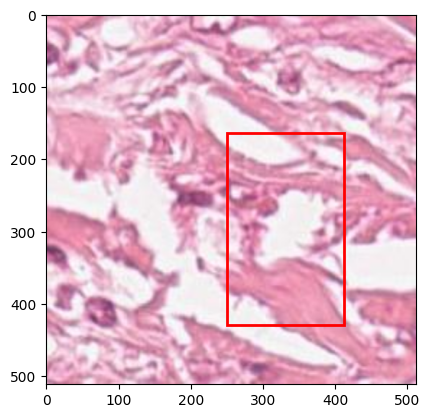

In [ ]:
import matplotlib.pyplot as plt

# Ensure model is on GPU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)
model.eval()

# Pick an image
img, target = valid_dataset[0]
img_tensor = img.unsqueeze(0).to(device)  # batch of 1

# Run model
with torch.no_grad():
    outputs = model(img_tensor)[0]

# Check predictions
if len(outputs['boxes']) == 0:
    print("No predicted boxes for this image.")
else:
    predicted_box = outputs['boxes'][0].cpu()
    score = outputs['scores'][0].cpu()
    print(f"Box: {predicted_box}, Score: {score}")

    # Visualize
    img_np = img.permute(1,2,0).cpu().numpy()
    plt.imshow(img_np)
    x1, y1, x2, y2 = predicted_box
    plt.gca().add_patch(plt.Rectangle((x1, y1), x2-x1, y2-y1,
                                      edgecolor='r', facecolor='none', linewidth=2))
    plt.show()


In [ ]:
import os

checkpoint_dir = "/kaggle/working"
print("📂 Files in working directory:")
print(os.listdir(checkpoint_dir))


📂 Files in working directory:
['model_epoch_14.pth', 'mitosis-dataset-cache', '.virtual_documents', 'comparison.png', 'train_features.pt']


In [ ]:
# 5️⃣ Create smaller subset (~7k images, 2:1 ratio)
desired_total = 7000
num_pos = (2 * desired_total) // 3  # ~4666
num_neg = desired_total - num_pos   # ~2334

sampled_positives = random.sample(positive_images, num_pos)
sampled_negatives = random.sample(negative_images, num_neg)

subset_images = sampled_positives + sampled_negatives
random.shuffle(subset_images)

print("Total subset images:", len(subset_images))
print(f"Sampled positives: {len(sampled_positives)}, Sampled negatives: {len(sampled_negatives)}")


Total subset images: 7000
Sampled positives: 4666, Sampled negatives: 2334


In [ ]:
import os
import random

# Path to training labels and images
train_labels_dir = '/kaggle/working/mitosis-dataset-cache/train/labels'
train_images_dir = '/kaggle/working/mitosis-dataset-cache/train/images'

# Lists to store positive and negative image filenames
positive_images = []
negative_images = []

# Check each label file
for label_file in os.listdir(train_labels_dir):
    label_path = os.path.join(train_labels_dir, label_file)

    # Read the label file
    with open(label_path, 'r') as f:
        lines = f.readlines()

    # If there is at least 1 object → positive
    if len(lines) > 0:
        positive_images.append(label_file.replace('.txt', '.jpg'))
    else:
        negative_images.append(label_file.replace('.txt', '.jpg'))

# Output counts
print(f"Total positive images: {len(positive_images)}")
print(f"Total negative images: {len(negative_images)}")

# ------------------------------
# Sample subset: 2:1 ratio (positives : negatives)
# For example, let's take all positives and half of them as negatives
num_pos = len(positive_images)
num_neg = num_pos // 2  # 2:1 ratio
sampled_negatives = random.sample(negative_images, num_neg)

# Combine to create final subset
subset_images = positive_images + sampled_negatives
random.shuffle(subset_images)

print(f"Total subset images: {len(subset_images)}")
print(f"Sampled positives: {len(positive_images)}, Sampled negatives: {len(sampled_negatives)}")


Total positive images: 10765
Total negative images: 15299
Total subset images: 16147
Sampled positives: 10765, Sampled negatives: 5382


In [ ]:
model.eval()
with torch.no_grad():
    # Get first batch
    images_batch, targets_batch = next(iter(valid_loader))

    # Convert list of images to device
    images = [img.to(device) for img in images_batch]

    # Run inference
    outputs = model(images)

print(outputs[0])  # Check first image predictions


{'boxes': tensor([[249.4543, 162.9905, 412.4449, 429.1937],
        [367.5947, 323.6848, 413.3377, 361.9794],
        [222.1822, 234.1186, 512.0000, 387.5896],
        [ 51.5139,   0.0000, 512.0000, 187.5508],
        [279.6140, 119.1743, 465.3208, 479.9727],
        [ 34.9283,   0.0000, 512.0000, 362.2336],
        [165.5275, 416.6780, 204.9208, 467.7025],
        [408.6703, 387.6692, 433.4824, 409.0176],
        [307.4759, 242.9116, 499.7971, 342.5200],
        [201.7843, 271.1998, 446.1985, 447.4493],
        [296.1345, 231.5920, 368.5127, 312.9169],
        [412.4104, 339.6678, 510.4426, 397.4621],
        [346.4409, 370.9423, 499.4359, 502.0757],
        [361.9936, 250.2135, 507.6748, 318.7180],
        [430.0538, 407.2804, 509.4694, 492.4946],
        [319.1048, 234.8366, 393.1973, 309.4840],
        [348.9437, 254.4855, 448.2885, 338.1675],
        [421.7943, 315.1207, 494.1739, 464.3036],
        [147.8491, 104.7425, 441.2653, 258.1345],
        [400.6549, 375.3453, 441.3860, 4

In [ ]:
import torch.nn.functional as F
from torchvision.ops import roi_align
import matplotlib.pyplot as plt
import numpy as np

model.eval()
prototypes = []  # To store (feature, cropped_image) tuples

# Get a batch from validation loader
images_batch, targets_batch = next(iter(valid_loader))
images = [img.to(device) for img in images_batch]

with torch.no_grad():
    outputs = model(images)  # Run inference

# For simplicity, process first image in batch
img_tensor = images[0]
output = outputs[0]  # Dict with boxes, labels, scores
boxes = output['boxes']
scores = output['scores']

# Keep high-confidence detections
threshold = 0.5
keep_idx = scores > threshold
boxes = boxes[keep_idx]

# Extract backbone features
backbone_feats = model.backbone(img_tensor.unsqueeze(0))['0']  # using layer0 feature map
feat_map = backbone_feats  # shape: [1, C, H, W]
_, C, H, W = feat_map.shape

# ROI Align each detected box
boxes_scaled = boxes.clone()
# Scale boxes from image pixels to feature map pixels
img_h, img_w = img_tensor.shape[1], img_tensor.shape[2]
boxes_scaled[:, 0] = boxes[:, 0] / img_w * W
boxes_scaled[:, 2] = boxes[:, 2] / img_w * W
boxes_scaled[:, 1] = boxes[:, 1] / img_h * H
boxes_scaled[:, 3] = boxes[:, 3] / img_h * H

roi_features = roi_align(feat_map, [boxes_scaled], output_size=(7,7))  # shape: [N, C, 7,7]

# Pool to get 1D feature vector per box
roi_vectors = F.adaptive_avg_pool2d(roi_features, (1,1)).squeeze(-1).squeeze(-1)  # shape: [N, C]

# Store prototypes
for i, vec in enumerate(roi_vectors):
    x1, y1, x2, y2 = boxes[i].cpu().numpy().astype(int)
    crop_img = img_tensor[:, y1:y2, x1:x2].cpu().permute(1,2,0).numpy()
    prototypes.append((vec.cpu(), crop_img))


In [ ]:
def find_top_k_prototypes(query_vec, train_features, k=3):
    sims = [F.cosine_similarity(query_vec.unsqueeze(0), feat.unsqueeze(0)).item()
            for feat, _ in train_features]
    top_k_idx = np.argsort(sims)[-k:][::-1]
    return [train_features[i][1] for i in top_k_idx]  # return cropped images


In [ ]:
import torch
import torch.nn.functional as F
from torchvision.ops import roi_align
from tqdm import tqdm
import os

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.eval()

# Parameters
batch_size = 4  # adjust based on GPU memory
resize_size = (256, 256)  # smaller size to speed up
save_every = 100  # save features after every 100 images
feature_file = "/kaggle/working/train_features.pt"

# Load existing features if any
if os.path.exists(feature_file):
    train_features = torch.load(feature_file)
    start_idx = len(train_features)
    print(f"Resuming feature extraction from index {start_idx}")
else:
    train_features = []
    start_idx = 0

# Iterate through training dataset
for idx in tqdm(range(start_idx, len(train_dataset))):
    img, target = train_dataset[idx]
    # Resize to smaller size
    img_resized = torch.nn.functional.interpolate(img.unsqueeze(0), size=resize_size, mode='bilinear', align_corners=False)
    img_resized = img_resized.squeeze(0).to(device)

    with torch.no_grad():
        # Forward through backbone
        backbone_feats = model.backbone(img_resized.unsqueeze(0))['0']  # use layer0 features
        _, C, H, W = backbone_feats.shape

        # Only process positive boxes
        boxes = target['boxes']
        if len(boxes) == 0:
            continue  # skip negative images

        # Scale boxes to feature map
        boxes_scaled = boxes.clone().to(device)
        img_h, img_w = img_resized.shape[1], img_resized.shape[2]
        boxes_scaled[:, 0] = boxes[:, 0] / img_w * W
        boxes_scaled[:, 2] = boxes[:, 2] / img_w * W
        boxes_scaled[:, 1] = boxes[:, 1] / img_h * H
        boxes_scaled[:, 3] = boxes[:, 3] / img_h * H

        # ROI Align
        roi_feats = roi_align(backbone_feats, [boxes_scaled], output_size=(7,7))
        roi_vectors = F.adaptive_avg_pool2d(roi_feats, (1,1)).squeeze(-1).squeeze(-1)  # [N, C]

        # Store vectors + cropped images
        for i, vec in enumerate(roi_vectors):
            x1, y1, x2, y2 = boxes[i].cpu().numpy().astype(int)
            crop_img = img[:, y1:y2, x1:x2].cpu().permute(1,2,0).numpy()
            train_features.append((vec.cpu(), crop_img))

    # Save every N images to avoid data loss
    if (idx+1) % save_every == 0:
        torch.save(train_features, feature_file)
        print(f"💾 Saved {len(train_features)} features at image {idx+1}")

# Final save
torch.save(train_features, feature_file)
print(f"✅ Feature extraction complete, total features: {len(train_features)}")


In [ ]:
import torch
torch.save(train_features, "/kaggle/working/train_features.pt")
print("✅ train_features.pt saved successfully!")


✅ train_features.pt saved successfully!


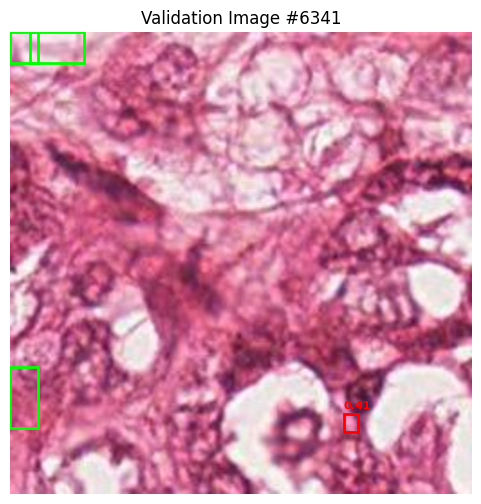

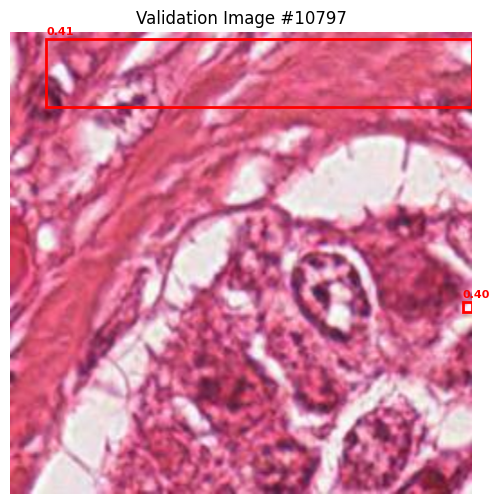

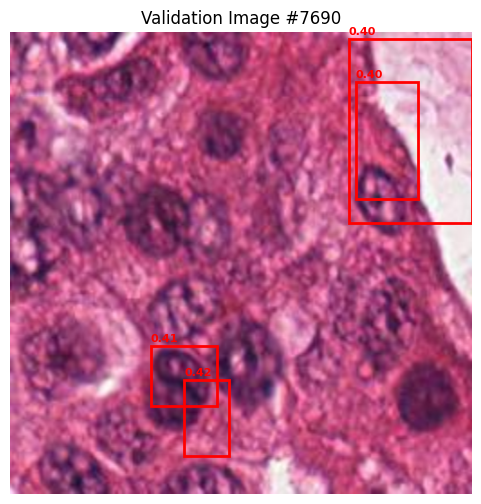

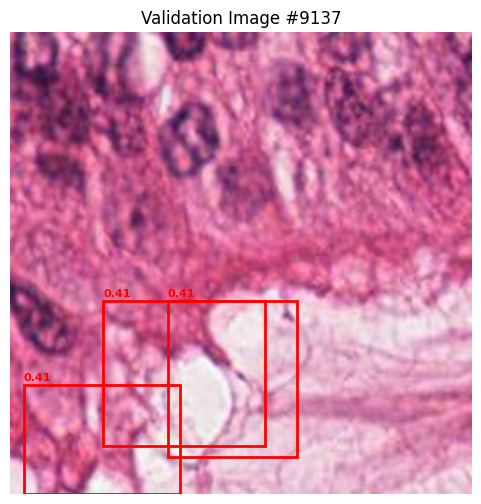

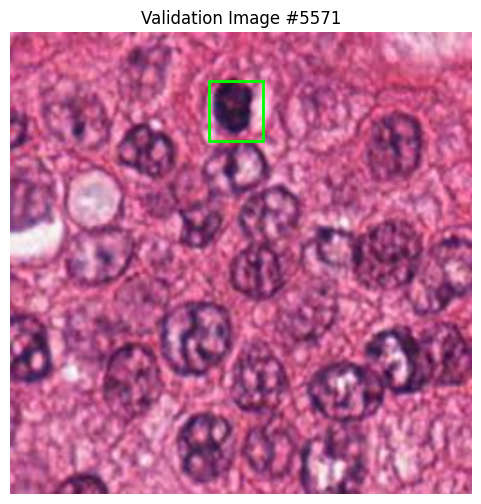

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import random
import torch

# Ensure model is in eval mode
model.eval()

# Pick random samples from validation set
num_images_to_show = 5
sample_indices = random.sample(range(len(valid_dataset)), num_images_to_show)

def plot_prediction(image, targets, outputs, idx):
    """
    Draw ground truth (green) and predicted boxes (red) on the image.
    """
    fig, ax = plt.subplots(1, figsize=(6, 6))
    img_np = image.permute(1, 2, 0).cpu().numpy()
    ax.imshow(img_np)
    ax.set_title(f"Validation Image #{idx+1}")

    # Ground truth boxes - green
    for box in targets['boxes']:
        x1, y1, x2, y2 = box
        rect = patches.Rectangle((x1, y1), x2-x1, y2-y1,
                                 linewidth=2, edgecolor='lime', facecolor='none')
        ax.add_patch(rect)

    # Predicted boxes - red
    for box, score in zip(outputs['boxes'], outputs['scores']):
        if score > 0.4:  # only show confident predictions
            x1, y1, x2, y2 = box
            rect = patches.Rectangle((x1, y1), x2-x1, y2-y1,
                                     linewidth=2, edgecolor='red', facecolor='none')
            ax.add_patch(rect)
            ax.text(x1, y1-5, f"{score:.2f}", color='red', fontsize=8, weight='bold')

    plt.axis('off')
    plt.show()


# Run inference and visualize
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

for idx in sample_indices:
    img, target = valid_dataset[idx]
    img_tensor = img.unsqueeze(0).to(device)

    with torch.no_grad():
        outputs = model(img_tensor)[0]

    plot_prediction(img, target, outputs, idx)


In [ ]:
import torch

def extract_features_fast(model, dataloader, device, sample_size=50):
    model.eval()
    images_list = []
    features_list = []
    count = 0

    with torch.no_grad():
        for batch in dataloader:
            imgs = batch[0]  # batch[0] is a tuple of tensors
            # Convert tuple to tensor
            if isinstance(imgs, tuple):
                imgs = torch.stack(imgs).to(device)
            else:
                imgs = imgs.to(device)

            images_list.append(imgs.cpu())

            # Forward pass through backbone
            feats = model.backbone(imgs)['0']  # use first layer feature map
            feats = feats.mean(dim=[2,3])  # global average pooling
            features_list.append(feats.cpu())

            count += imgs.size(0)
            if count >= sample_size:
                break

    images_tensor = torch.cat(images_list)[:sample_size]
    features_tensor = torch.cat(features_list)[:sample_size]

    return features_tensor, images_tensor

# Usage
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

print("🔸 Extracting features from a small batch for demo...")
train_features, train_images = extract_features_fast(model, train_loader, device)
print(f"✅ Features shape: {train_features.shape}")
print(f"✅ Images shape: {train_images.shape}")


🔸 Extracting features from a small batch for demo...
✅ Features shape: torch.Size([50, 256])
✅ Images shape: torch.Size([50, 3, 512, 512])


/usr/local/lib/python3.11/dist-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(


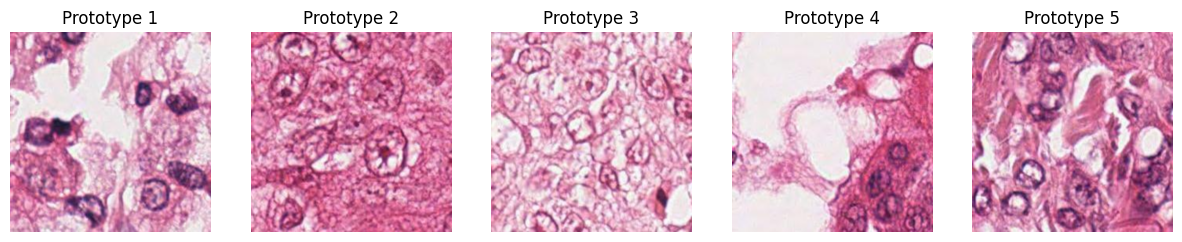

In [ ]:
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans

# Number of prototypes you want to show
num_prototypes = 5

# KMeans clustering on extracted features
kmeans = KMeans(n_clusters=num_prototypes, random_state=42)
kmeans.fit(train_features.numpy())
prototype_indices = []

# Find the nearest image to each cluster center
for center in kmeans.cluster_centers_:
    distances = torch.cdist(torch.tensor(center).unsqueeze(0), train_features)
    nearest_idx = torch.argmin(distances)
    prototype_indices.append(nearest_idx.item())

# Visualize prototypes
plt.figure(figsize=(15, 3))
for i, idx in enumerate(prototype_indices):
    img = train_images[idx].permute(1,2,0).numpy()
    plt.subplot(1, num_prototypes, i+1)
    plt.imshow(img)
    plt.axis('off')
    plt.title(f'Prototype {i+1}')
plt.show()


In [ ]:
def extract_features_demo(model, dataloader, device, sample_size=50):
    model.eval()
    features_list = []
    images_list = []
    count = 0

    with torch.no_grad():
        for batch in dataloader:
            imgs_list = batch[0]  # this is a list of tensors
            # Stack into a single tensor [batch_size, 3, H, W]
            imgs = torch.stack(imgs_list).to(device)

            # Forward pass through backbone (FasterRCNN's backbone)
            feats = model.backbone(imgs)['0']  # first layer feature map
            feats = torch.nn.functional.adaptive_avg_pool2d(feats, (1,1)).squeeze(-1).squeeze(-1)

            features_list.append(feats.cpu())
            images_list.append(imgs.cpu())

            count += imgs.size(0)
            if count >= sample_size:
                break

    features = torch.cat(features_list, dim=0)[:sample_size]
    images = torch.cat(images_list, dim=0)[:sample_size]

    return features, images


In [ ]:
from torch.utils.data import Subset, DataLoader

# Take first 10 samples from train_dataset as demo test dataset
test_dataset_demo = Subset(train_dataset, list(range(10)))

# Create DataLoader
test_loader = DataLoader(
    test_dataset_demo,
    batch_size=1,  # one image at a time for Grad-CAM
    shuffle=False,
    collate_fn=lambda x: tuple(zip(*x))
)


🔹 Visualizing Grad-CAM on demo images...


/usr/local/lib/python3.11/dist-packages/torch/nn/modules/module.py:1830: FutureWarning: Using a non-full backward hook when the forward contains multiple autograd Nodes is deprecated and will be removed in future versions. This hook will be missing some grad_input. Please use register_full_backward_hook to get the documented behavior.
  self._maybe_warn_non_full_backward_hook(args, result, grad_fn)


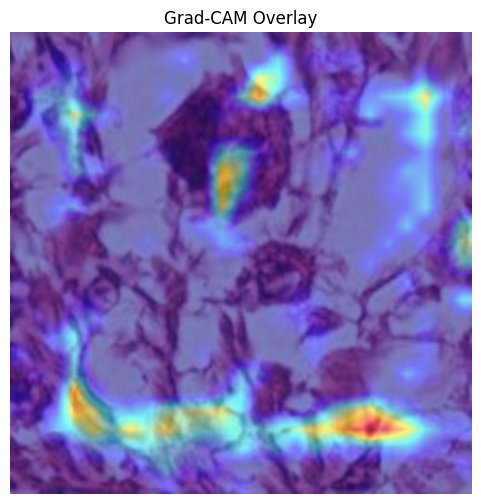

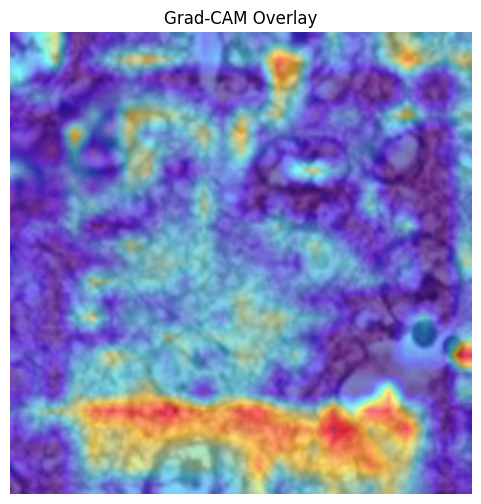

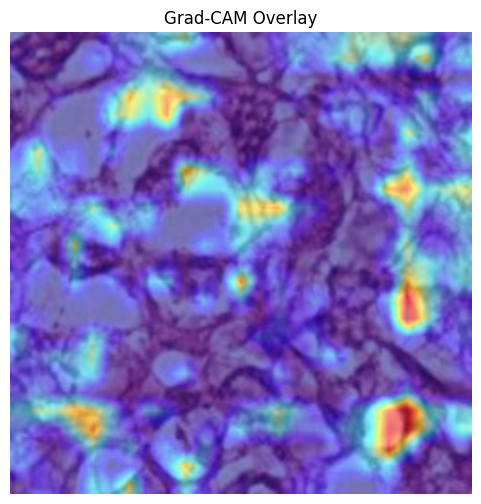

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)
model.eval()

print("🔹 Visualizing Grad-CAM on demo images...")
visualize_gradcam(model, test_loader, device)
